<a href="https://colab.research.google.com/github/mishti127/Deep-learning/blob/main/Mini%20batch%20GD.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Epoch 0: Loss = 0.4857
Epoch 500: Loss = 0.2143

ACTUAL vs PREDICTED (Mini-Batch GD)
Input [0 0] | Actual: 0 | Predicted: 0 (value = 0.016)
Input [0 1] | Actual: 0 | Predicted: 0 (value = 0.189)
Input [1 0] | Actual: 0 | Predicted: 0 (value = 0.191)
Input [1 1] | Actual: 1 | Predicted: 1 (value = 0.770)



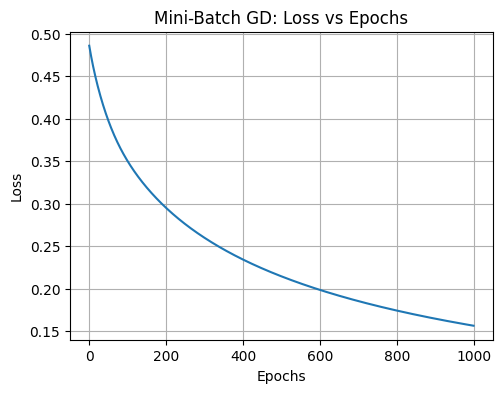

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# Dataset (AND gate)
X = np.array([[0,0],[0,1],[1,0],[1,1]])
y = np.array([[0],[0],[0],[1]])

# Parameters
lr = 0.1
epochs = 1000
batch_size = 2

np.random.seed(1)
weights = np.random.randn(2,1)
bias = 0.0

loss_history = []

def sigmoid(x):
    return 1 / (1 + np.exp(-x))

def sigmoid_derivative(y):
    return y * (1 - y)

# Training
for epoch in range(epochs):
    for i in range(0, len(X), batch_size):
        Xb = X[i:i+batch_size]
        yb = y[i:i+batch_size]

        z = np.dot(Xb, weights) + bias
        output = sigmoid(z)

        error = yb - output
        d_output = error * sigmoid_derivative(output)

        weights += lr * np.dot(Xb.T, d_output)
        bias += lr * np.sum(d_output)

    loss = np.mean(np.abs(y - sigmoid(np.dot(X,weights)+bias)))
    loss_history.append(loss)

    if epoch % 500 == 0:
        print(f"Epoch {epoch}: Loss = {loss:.4f}")

# Final prediction
final_output = sigmoid(np.dot(X, weights) + bias)
predicted = (final_output > 0.5).astype(int)

print("\nACTUAL vs PREDICTED (Mini-Batch GD)")
for i in range(len(X)):
    print(f"Input {X[i]} | Actual: {y[i][0]} | "
          f"Predicted: {predicted[i][0]} "
          f"(value = {final_output[i][0]:.3f})")
print()
# Plots
plt.figure(figsize=(12,4))

plt.subplot(1,2,1)
plt.plot(loss_history)
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.title("Mini-Batch GD: Loss vs Epochs")
plt.grid(True)

plt.show()
